# GOAPified Adaptive RAG

This notebook demonstrates how **LangGOAP** replaces the hardcoded conditional edges in
[LangGraph's Adaptive RAG](https://langchain-ai.github.io/langgraph/tutorials/rag/langgraph_adaptive_rag/)
with formal GOAP planning.

## What This Covers

The original Adaptive RAG uses three hardcoded conditional edges to route between
vectorstore retrieval, web search, document grading, and answer generation.
This notebook replaces the **retrieval routing** and **failure recovery** portions
with GOAP A\* planning:

| Aspect | Original LangGraph | GOAPified (LangGOAP) |
|--------|-------------------|---------------------|
| Retrieval routing | LLM-based `route_question` edge | A\* picks lowest-cost retrieval path |
| Failure recovery | Hardcoded edge back to web search | Observer detects deviation, triggers replanning |
| Plan verification | None — LLM may hallucinate routing | A\* guarantees plan is achievable |

> **Note:** The original also includes a `transform_query` step that rewrites the
> question after failed document grading.  Full query-transform routing requires
> action blacklisting (so the planner stops re-selecting the same failing retrieval
> path), which is planned for a future LangGOAP release.

## Architecture

Each RAG component becomes a **GOAP action** with typed preconditions and effects:

```
retrieve_documents:  has_question → has_documents           (cost=1)
web_search:          has_question → has_documents           (cost=2)
grade_documents:     has_documents → has_relevant_documents (cost=1)
generate_answer:     has_relevant_documents → answer_ready  (cost=1)
```

The A\* planner finds the cheapest path from the initial state to the goal.

In [1]:
from typing import Any

from langchain_core.messages import HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI

from langgoap import ActionSpec, GoalSpec, GoapGraph, ReplanStrategy

# Requires OPENAI_API_KEY environment variable
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

## RAG Action Execute Functions

Each action wraps an LLM call. `retrieve_documents` and `web_search` handle
the two retrieval paths; `grade_documents` filters for relevance;
`generate_answer` produces the final response.

In [2]:
def retrieve_documents(ws: dict[str, Any]) -> dict[str, Any]:
    """LLM generates document excerpts relevant to the question."""
    question = ws.get("question", "")
    response = llm.invoke(
        [
            SystemMessage(
                content=(
                    "You are a document retrieval system. Given a question, "
                    "generate 2 relevant document excerpts that would help "
                    "answer it. Return each excerpt on its own line, prefixed "
                    "with '- '."
                )
            ),
            HumanMessage(content=f"Retrieve documents for: {question}"),
        ]
    )
    lines = [
        line.strip().lstrip("- ").strip()
        for line in response.content.strip().split("\n")
        if line.strip() and line.strip() != "-"
    ]
    docs = [{"page_content": line, "source": "vectorstore"} for line in lines if line]
    return {"has_documents": True, "documents": docs}


def web_search(ws: dict[str, Any]) -> dict[str, Any]:
    """LLM generates web-style search results for the question."""
    question = ws.get("question", "")
    response = llm.invoke(
        [
            SystemMessage(
                content=(
                    "You are a web search tool. Given a question, provide "
                    "1-2 concise, factual web search results. Return each "
                    "on its own line, prefixed with '- '."
                )
            ),
            HumanMessage(content=f"Web search for: {question}"),
        ]
    )
    lines = [
        line.strip().lstrip("- ").strip()
        for line in response.content.strip().split("\n")
        if line.strip() and line.strip() != "-"
    ]
    docs = [{"page_content": line, "source": "web"} for line in lines if line]
    return {"has_documents": True, "documents": docs}


def grade_documents(ws: dict[str, Any]) -> dict[str, Any]:
    """LLM grades each document for relevance; keeps only relevant ones."""
    docs = ws.get("documents", [])
    question = ws.get("question", "")
    relevant = []
    for doc in docs:
        content = doc.get("page_content", str(doc))
        response = llm.invoke(
            [
                SystemMessage(
                    content=(
                        "You are a document relevance grader. Given a question "
                        "and a document, determine if the document is relevant "
                        "to answering the question. Respond with EXACTLY 'yes' "
                        "or 'no'."
                    )
                ),
                HumanMessage(
                    content=(
                        f"Question: {question}\n\n"
                        f"Document: {content}\n\n"
                        "Is this document relevant? (yes/no)"
                    )
                ),
            ]
        )
        if "yes" in response.content.strip().lower():
            relevant.append(doc)
    return {"has_relevant_documents": len(relevant) > 0, "relevant_documents": relevant}


def generate_answer(ws: dict[str, Any]) -> dict[str, Any]:
    """LLM generates a grounded answer from the relevant documents."""
    docs = ws.get("relevant_documents", ws.get("documents", []))
    question = ws.get("question", "")
    context = "\n\n".join(doc.get("page_content", str(doc)) for doc in docs)
    response = llm.invoke(
        [
            SystemMessage(
                content=(
                    "You are a RAG assistant. Given a question and supporting "
                    "documents, generate a concise, grounded answer. Only use "
                    "information from the provided documents."
                )
            ),
            HumanMessage(
                content=(
                    f"Question: {question}\n\n"
                    f"Documents:\n{context}\n\n"
                    "Generate an answer:"
                )
            ),
        ]
    )
    return {"answer_ready": True, "generation": response.content.strip()}


def hallucination_validator(
    pre_state: dict[str, Any], post_state: dict[str, Any]
) -> bool:
    """Effect validator: checks if the generated answer is grounded in the documents."""
    generation = post_state.get("generation", "")
    docs = pre_state.get("relevant_documents", pre_state.get("documents", []))
    if not generation or not docs:
        return False
    context = "\n".join(doc.get("page_content", str(doc)) for doc in docs)
    response = llm.invoke(
        [
            SystemMessage(
                content=(
                    "You are a hallucination grader. Given source documents "
                    "and a generated answer, determine if the answer is "
                    "grounded in the documents. Respond with EXACTLY 'yes' "
                    "if grounded or 'no' if it contains unsupported claims."
                )
            ),
            HumanMessage(
                content=(
                    f"Documents:\n{context}\n\n"
                    f"Answer: {generation}\n\n"
                    "Is the answer grounded? (yes/no)"
                )
            ),
        ]
    )
    return "yes" in response.content.strip().lower()

## Build GOAP Action Specifications

Each function above is wrapped in an `ActionSpec` with:
- **preconditions**: what must be true in world state before the action can execute
- **effects**: what the action guarantees after execution (used by A\* planner)
- **cost**: numeric cost used by A\* to find the optimal plan

`generate_answer` also carries a **hallucination validator** — an `effect_validator`
that asks the LLM whether the generated answer is grounded in the source documents.

In [3]:
def build_rag_actions(*, retrieve_cost: float = 1.0, web_cost: float = 2.0) -> list[ActionSpec]:
    """Build the Adaptive RAG action set with configurable retrieval costs."""
    return [
        ActionSpec(
            name="retrieve_documents",
            preconditions={"has_question": True},
            effects={"has_documents": True},
            cost=retrieve_cost,
            execute=retrieve_documents,
        ),
        ActionSpec(
            name="web_search",
            preconditions={"has_question": True},
            effects={"has_documents": True},
            cost=web_cost,
            execute=web_search,
        ),
        ActionSpec(
            name="grade_documents",
            preconditions={"has_documents": True},
            effects={"has_relevant_documents": True},
            cost=1.0,
            execute=grade_documents,
        ),
        ActionSpec(
            name="generate_answer",
            preconditions={"has_relevant_documents": True},
            effects={"answer_ready": True},
            cost=1.0,
            execute=generate_answer,
            effect_validator=hallucination_validator,
        ),
    ]


actions = build_rag_actions()
print(f"{len(actions)} actions:")
for a in actions:
    print(f"  {a.name:<22s} cost={a.cost}  pre={dict(a.preconditions)}  eff={dict(a.effects)}")

4 actions:
  retrieve_documents     cost=1.0  pre={'has_question': True}  eff={'has_documents': True}
  web_search             cost=2.0  pre={'has_question': True}  eff={'has_documents': True}
  grade_documents        cost=1.0  pre={'has_documents': True}  eff={'has_relevant_documents': True}
  generate_answer        cost=1.0  pre={'has_relevant_documents': True}  eff={'answer_ready': True}


### GOAP Execution Graph

The planner discovers a plan, the executor runs each action, and the
observer checks progress — replanning automatically if something fails.

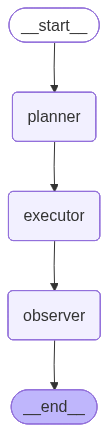

In [4]:
from IPython.display import Image, display

graph = GoapGraph(actions=actions)
display(Image(graph.compile().get_graph().draw_mermaid_png()))

## Happy Path: Vectorstore Retrieval

The planner discovers the optimal path: `retrieve_documents → grade_documents → generate_answer`.
It prefers vectorstore retrieval (cost=1) over web search (cost=2).

In [5]:
result = GoapGraph(actions=actions).invoke(
    goal=GoalSpec(conditions={"answer_ready": True}),
    world_state={
        "has_question": True,
        "question": "What are agent memory types?",
    },
)

print(f"Status: {result['status']}")
print(f"Answer: {result['world_state']['generation']}")
print(f"Actions executed: {[h.action_name for h in result['execution_history'] if h.success]}")

Status: goal_achieved
Answer: Agent memory types include short-term memory, long-term memory, and working memory. Short-term memory holds information temporarily for immediate tasks, long-term memory stores knowledge and experiences over time, and working memory is used for actively processing and manipulating information during problem-solving. Additionally, in artificial intelligence, there are episodic memory, which records specific events, and semantic memory, which contains general knowledge about the world. These memory types help agents learn from past interactions and enhance their decision-making abilities.
Actions executed: ['retrieve_documents', 'grade_documents', 'generate_answer']


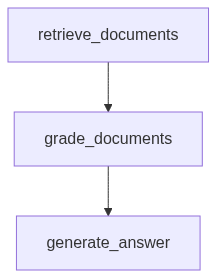

In [6]:
from langchain_core.runnables.graph_mermaid import draw_mermaid_png as _draw_png
from langgoap.viz.mermaid import render_mermaid

display(Image(_draw_png(render_mermaid(result["plan"]))))

## Cost-Based Routing

When both retrieval paths are available, A\* picks the lower-cost option.
This replaces the original's LLM-based `route_question` conditional edge.

In [7]:
result = GoapGraph(actions=build_rag_actions(retrieve_cost=1.0, web_cost=5.0)).invoke(
    goal=GoalSpec(conditions={"answer_ready": True}),
    world_state={"has_question": True, "question": "agent architectures"},
)

successful = [h.action_name for h in result["execution_history"] if h.success]
print(f"Planner chose: {successful[0]}")
print(f"Full sequence: {successful}")

Planner chose: retrieve_documents
Full sequence: ['retrieve_documents', 'grade_documents', 'generate_answer']


## Web Search Fallback

When the vectorstore is unavailable (action not registered), the planner
automatically routes through web search — no conditional edges needed.

In [8]:
# Build actions with only web_search (no vectorstore retrieval)
web_only_actions = [a for a in build_rag_actions() if a.name != "retrieve_documents"]

result = GoapGraph(actions=web_only_actions).invoke(
    goal=GoalSpec(conditions={"answer_ready": True}),
    world_state={"has_question": True, "question": "2024 NFL draft picks"},
)

print(f"Status: {result['status']}")
print(f"Actions: {[h.action_name for h in result['execution_history'] if h.success]}")
print(f"Answer: {result['world_state']['generation'][:150]}...")

Status: goal_achieved
Actions: ['web_search', 'grade_documents', 'generate_answer']
Answer: The 2024 NFL Draft is set for April 25 to April 27, 2024, in Detroit, Michigan. Currently, the Chicago Bears hold the first overall pick, followed by ...


## Replanning on Failure

When an action raises an exception, the observer detects the failure and
triggers replanning from the current partial state.

In [9]:
call_count = {"retrieve": 0}

# Get the real retrieve_documents execute from factory-created actions
_real_retrieve = next(a.execute for a in actions if a.name == "retrieve_documents")


def flaky_retrieve(ws: dict[str, Any]) -> dict[str, Any]:
    """Fails on first call, succeeds on subsequent calls."""
    call_count["retrieve"] += 1
    if call_count["retrieve"] == 1:
        raise ConnectionError("Vector store unavailable")
    return _real_retrieve(ws)


# Build actions with flaky retrieve swapped in
replan_actions = [
    ActionSpec(
        name=a.name,
        preconditions=dict(a.preconditions),
        effects=dict(a.effects),
        cost=a.cost,
        execute=flaky_retrieve if a.name == "retrieve_documents" else a.execute,
    )
    for a in actions
]

result = GoapGraph(actions=replan_actions).invoke(
    goal=GoalSpec(conditions={"answer_ready": True}),
    world_state={"has_question": True, "question": "agent memory"},
)

print(f"Status: {result['status']}")
print(f"Replan count: {result['replan_count']}")
failures = [h for h in result["execution_history"] if not h.success]
print(f"Failures: {[(f.action_name, f.error) for f in failures]}")
print(f"Final answer: {result['world_state']['generation'][:120]}...")

Action 'retrieve_documents' failed: Vector store unavailable


Status: goal_achieved
Replan count: 1
Failures: [('retrieve_documents', 'Vector store unavailable')]
Final answer: Agent memory is the capability of an artificial intelligence agent to retain and recall information from past interactio...


## Two-Tier State: Planning Flags + Rich Data

LangGOAP separates **planning state** (hashable boolean flags for A\*) from
**execution context** (rich data like document lists, user metadata).
Both flow through the pipeline, but only planning flags are used by A\*.

In [10]:
result = GoapGraph(actions=actions).invoke(
    goal=GoalSpec(conditions={"answer_ready": True}),
    world_state={
        "has_question": True,
        "question": "What is GOAP planning?",
        "user_id": "test-user-123",  # Non-planning metadata
    },
)

ws = result["world_state"]
print(f"Documents (list): {type(ws['documents']).__name__}, count={len(ws['documents'])}")
print(f"Relevant docs (list): {type(ws['relevant_documents']).__name__}")
print(f"User metadata preserved: user_id={ws['user_id']}")

Documents (list): list, count=2
Relevant docs (list): list
User metadata preserved: user_id=test-user-123


## Unreachable Goals

When no action chain can reach the goal, the planner reports `no_plan`
instead of hallucinating a path.

In [11]:
# Only retrieve_documents is available — can't reach answer_ready
incomplete_actions = [a for a in actions if a.name == "retrieve_documents"]

result = GoapGraph(actions=incomplete_actions).invoke(
    goal=GoalSpec(conditions={"answer_ready": True}),
    world_state={"has_question": True},
)

print(f"Status: {result['status']}")

A* found no plan for goal {'answer_ready': True} — Goal condition(s) ['answer_ready'] cannot be produced by any available action. Add an action whose effects include these keys, or check for typos in the goal conditions.


Status: no_plan
